# barrierQP

Mehrotra's method asks two Newton questions per iteration and pays for one KKT
factorization. This notebook solves a small QP with the production
`barrierqp.Solver`, then takes the corrector apart on a second QP.

In [1]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)   # dense KKT solves want float64
import jax.numpy as jnp
import barrierqp

In [2]:
# A pentagon: the square [-1, 1]^2 cut by the diagonal 0.625 (x1 + x2) <= 1.
G = np.array([[1., 0.], [0., 1.], [0.625, 0.625], [-1., 0.], [0., -1.]])
h = np.ones(5)
P = np.array([[2.0, 0.5], [0.5, 1.5]])
q = np.array([-2.7, -2.175])
A, b = np.zeros((0, 2)), np.zeros(0)          # no equality rows

print(f"variables:    {P.shape[0]}")
print(f"equalities:   {A.shape[0]}")
print(f"inequalities: {G.shape[0]}")

variables:    2
equalities:   0
inequalities: 5


In [3]:
result = barrierqp.Solver(P, q, A, b, G, h).solve()
x = np.asarray(result.x); z = np.asarray(result.z)
objective = float(0.5 * x @ P @ x + q @ x)
primal = float(np.max(np.maximum(G @ x - h, 0.0), initial=0.0))
kkt = float(np.max(np.abs(P @ x + q + G.T @ z), initial=0.0))

print(f"status:          {result.status}")
print(f"x:               [{x[0]:.6f}, {x[1]:.6f}]")
print(f"objective:       {objective:.6f}")
print(f"iterations:      {result.iterations}")
print(f"factorizations:  {result.factorizations}")
print(f"Newton solves:   {result.newton_solves}")
print(f"primal residual: {primal:.2e}")
print(f"KKT residual:    {kkt:.2e}")

status:          solved
x:               [0.850000, 0.750000]
objective:       -2.463125
iterations:      6
factorizations:  6
Newton solves:   12
primal residual: 0.00e+00
KKT residual:    8.47e-10


Six iterations, six factorizations, twelve solves: factorization reuse is visible
in the counters. What the counters cannot show is why the second right-hand side
is worth solving for.

## Predictor–corrector: three right-hand sides, one Jacobian

Every direction below is a Newton direction on the same perturbed KKT equations at
the same iterate, so all three share one Jacobian $J_k$ and one factorization. Only
the complementarity row of the right-hand side differs — and complementarity is the
only nonlinear KKT equation, whose exact product

$$
(s + \Delta s)\odot(z + \Delta z)
= s\odot z + Z\Delta s + S\Delta z + \Delta s\odot\Delta z
$$

the linearization truncates at the last term.

| method | complementarity right-hand side | cost |
|---|---|---|
| `affine Newton` | $-\,s\odot z$ | 1 factorization + 1 solve |
| `centered Newton` | $-\,s\odot z + \sigma\mu\mathbf 1$ | 1 factorization + 2 solves |
| `predictor–corrector` | $-\,s\odot z + \sigma\mu\mathbf 1 - \Delta s_\mathrm{aff}\odot\Delta z_\mathrm{aff}$ | 1 factorization + 2 solves |

The affine step *is* a Newton step, taking $\mu_\mathrm{target}=0$. Centering uses
$\sigma = (\mu_\mathrm{aff}/\mu)^3$, measured from how far that step could go. The
corrector adds back the truncated term — measured, not guessed.

In [4]:
# A regular octagon: eight unit-norm rows, so nothing below can be blamed on row
# scaling or preconditioning. With P = I the objective is a squared distance to a
# target c placed outside the set, and the optimum is a sharp vertex.
theta = np.pi / 4 * np.arange(8)                        # 0, 45, ..., 315 degrees
G_oct = np.stack([np.cos(theta), np.sin(theta)], axis=1)
h_oct = np.ones(8)
P_oct = np.eye(2)
c = 3.0 * np.array([np.cos(np.deg2rad(36)), np.sin(np.deg2rad(36))])
q_oct = -c                          # 0.5 x'x - c'x is 0.5||x - c||^2 up to a constant
A_oct, b_oct = np.zeros((0, 2)), np.zeros(0)            # no equality rows

active = [0, 1]                                         # the 0 and 45 degree normals
x_star = np.array([1.0, np.sqrt(2.0) - 1.0])            # where those two rows meet
z_star = np.linalg.solve(G_oct[active] @ G_oct[active].T, G_oct[active] @ (c - x_star))

assert np.allclose(np.linalg.norm(G_oct, axis=1), 1.0)              # unit rows
assert np.all(G_oct @ x_star - h_oct <= 1e-15)                      # feasible
assert np.allclose((G_oct @ x_star - h_oct)[active], 0.0)           # both rows tight
assert np.all(z_star > 0)                                           # strict complementarity
assert np.allclose(P_oct @ x_star + q_oct + G_oct[active].T @ z_star, 0.0)  # stationarity

print(f"target c:    [{c[0]:.6f}, {c[1]:.6f}]   ||c|| = {np.linalg.norm(c):.1f}, outside")
print(f"x*:          [{x_star[0]:.6f}, {x_star[1]:.6f}]")
print(f"z* on rows {active}: [{z_star[0]:.6f}, {z_star[1]:.6f}]")
print(f"slack at x*: {np.array2string(h_oct - G_oct @ x_star, precision=3)}")

target c:    [2.427051, 1.763356]   ||c|| = 3.0, outside
x*:          [1.000000, 0.414214]
z* on rows [0, 1]: [0.077909, 1.907975]
slack at x*: [0.    0.    0.586 1.414 2.    2.    1.414 0.586]


In [5]:
# Built from the production pieces verbatim. All three modes linearize the same KKT
# equations at the same point, so the Jacobian is a property of the point alone --
# only the complementarity row of the right-hand side depends on the mode.
from jax.scipy.linalg import lu_factor

from barrierqp.solver import (TAU, Problem, State, form_kkt, fraction_to_boundary,
                              inf_norm, init_state, residuals, solve_direction, step,
                              stop_test, tolerances)

EPS = 1e-8       # eps_abs = eps_rel, the production default
MAX_FACT = 30    # cap on outer iterations, which is also the cap on factorizations

problem = Problem(*(jnp.asarray(v, jnp.float64)
                    for v in (P_oct, q_oct, A_oct, b_oct, G_oct, h_oct)))
start = init_state(problem)                                        # x = 0, s = 1, z = 1
assert np.allclose(np.asarray(start.x), 0.0)
assert np.allclose(G_oct @ np.asarray(start.x) + np.asarray(start.s), h_oct)   # feasible
assert np.allclose(np.asarray(start.s) * np.asarray(start.z), 1.0)   # exactly centered


def newton_direction(problem, state, mode):
    """A Newton direction for one of the three complementarity right-hand sides.

    Returns the direction, the Newton solves it cost, and the KKT matrix it used --
    the same matrix for every mode at a given state.
    """
    x, y, z, s = state.x, state.y, state.z, state.s
    m_in = problem.h.shape[0]
    r_dual, r_eq, r_ineq, mu = residuals(problem, x, y, z, s)

    D = z / s
    K = form_kkt(problem, D)      # the Jacobian: set by the point, not by the mode
    lu = lu_factor(K)             # the one factorization

    # affine Newton: the uncentered predictor, complementarity target mu = 0.
    dx_a, dy_a, dz_a, ds_a, _ = solve_direction(
        K, lu, problem.G, z, s, D, r_dual, r_eq, r_ineq, -(s * z))
    if mode == "affine":
        return (dx_a, dy_a, dz_a, ds_a), 1, K

    # How far the affine step could go decides how much to recenter. Both remaining
    # modes compute sigma exactly as production does.
    a_p = fraction_to_boundary(s, ds_a, 1.0)
    a_d = fraction_to_boundary(z, dz_a, 1.0)
    mu_aff = (s + a_p * ds_a) @ (z + a_d * dz_a) / m_in
    sigma = jnp.clip((mu_aff / mu) ** 3, 0.0, 1.0)
    c_corr = -(s * z) + sigma * mu                  # centered Newton target
    if mode == "pc":
        c_corr = c_corr - ds_a * dz_a               # the miss, measured not guessed
    direction = solve_direction(                    # second right-hand side, same lu
        K, lu, problem.G, z, s, D, r_dual, r_eq, r_ineq, c_corr)[:4]
    return direction, 2, K


def ablation_step(problem, state, mode):
    """One outer iteration: one KKT factorization, one or two Newton solves."""
    (dx, dy, dz, ds), solves, _ = newton_direction(problem, state, mode)
    x, y, z, s = state.x, state.y, state.z, state.s
    alpha_p = fraction_to_boundary(s, ds, TAU)
    alpha_d = fraction_to_boundary(z, dz, TAU)
    x_new, s_new = x + alpha_p * dx, s + alpha_p * ds
    y_new, z_new = y + alpha_d * dy, z + alpha_d * dz
    done = stop_test(problem, x_new, y_new, z_new, s_new, EPS, EPS)   # production test
    return State(x_new, y_new, z_new, s_new, done, state.iteration + 1), solves


# One Jacobian, three right-hand sides: the matrix really does not depend on the mode.
mats = [np.asarray(newton_direction(problem, start, m)[2])
        for m in ("affine", "center", "pc")]
assert all(np.array_equal(mats[0], M) for M in mats[1:])
print(f"KKT matrix is {mats[0].shape[0]}x{mats[0].shape[1]} and bit-identical across "
      f"all three right-hand sides")

KKT matrix is 2x2 and bit-identical across all three right-hand sides


In [6]:
# The "pc" branch must not be a private variant of Mehrotra. From the same start it
# has to reproduce barrierqp's own step, component by component, in float64.
mine, prod, worst = start, start, 0.0
for _ in range(10):
    mine, _ = ablation_step(problem, mine, "pc")
    prod = step(problem, prod, EPS, EPS)
    worst = max(worst, *(float(np.max(np.abs(np.asarray(a) - np.asarray(b)), initial=0.0))
                         for a, b in ((mine.x, prod.x), (mine.y, prod.y),
                                      (mine.z, prod.z), (mine.s, prod.s))))
assert worst < 1e-11, worst
print(f"ablation 'pc' vs production step over 10 iterations: "
      f"max |diff| in (x, y, z, s) = {worst:.3e}")

ablation 'pc' vs production step over 10 iterations: max |diff| in (x, y, z, s) = 0.000e+00


In [7]:
# Same problem, same start, same production stop test, same cap for all three.
METHODS = ("affine", "center", "pc")
LABEL = {"affine": "affine Newton", "center": "centered Newton",
         "pc": "predictor–corrector"}


def record(state, solves):
    """One ledger row.

    Residuals are stored as ratios to the production tolerances, recomputed at this
    same iterate by the same `tolerances` call `stop_test` uses. A ratio of 1 is
    therefore exactly the threshold, and the three ratios are commensurable.
    """
    r_dual, r_eq, r_ineq, mu = residuals(problem, state.x, state.y, state.z, state.s)
    eps_p, eps_d, eps_g = (float(v) for v in tolerances(
        problem, state.x, state.y, state.z, state.s, EPS, EPS))
    prim = float(jnp.maximum(inf_norm(r_eq), inf_norm(r_ineq)))
    dual = float(inf_norm(r_dual))
    sz = np.asarray(state.s) * np.asarray(state.z)
    gap, mu = float(sz.sum()), float(mu)
    ratios = (prim / eps_p, dual / eps_d, gap / eps_g)
    return dict(k=int(state.iteration), solves=solves, x=np.asarray(state.x), state=state,
                prim=prim, dual=dual, gap=gap, mu=mu,
                prim_ratio=ratios[0], dual_ratio=ratios[1], gap_ratio=ratios[2],
                kkt_ratio=max(ratios), eps=(eps_p, eps_d, eps_g),
                centrality=float(np.linalg.norm(sz - mu) / (mu * np.sqrt(sz.size))))


def run(mode):
    """Iterate to the cap; the outer iteration count is the factorization count."""
    state, trace, solves = start, [], 0
    trace.append(record(state, 0))
    for _ in range(MAX_FACT):
        state, ns = ablation_step(problem, state, mode)
        solves += ns
        if not bool(jnp.all(jnp.isfinite(jnp.concatenate([state.x, state.z, state.s])))):
            return trace, "numerical_error", state    # a blown-up iterate is reported, not hidden
        trace.append(record(state, solves))
        if bool(state.converged):
            return trace, "solved", state
    return trace, "not converged", state


traces, status, finals = {}, {}, {}
for mode in METHODS:
    traces[mode], status[mode], finals[mode] = run(mode)

for mode in METHODS:
    print(f"{LABEL[mode]}   (k = outer iterations = KKT factorizations; "
          f"ratios are to the production tolerances, so 1 is the threshold)")
    print(f"{'k':>3} {'solves':>7} {'r_dual/eps_d':>13} {'gap/eps_g':>11} "
          f"{'KKT ratio':>11} {'centrality':>11}")
    for r in traces[mode]:
        print(f"{r['k']:>3} {r['solves']:>7} {r['dual_ratio']:>13.2e} "
              f"{r['gap_ratio']:>11.2e} {r['kkt_ratio']:>11.2e} {r['centrality']:>11.3f}")
    print(f"-> {status[mode]}\n")

affine Newton   (k = outer iterations = KKT factorizations; ratios are to the production tolerances, so 1 is the threshold)
  k  solves  r_dual/eps_d   gap/eps_g   KKT ratio  centrality
  0       0      7.08e+07    8.00e+08    8.00e+08       0.000
  1       1      2.14e+07    8.14e+07    8.14e+07       0.488
  2       2      6.34e+06    1.48e+07    1.48e+07       0.935
  3       3      1.48e+06    2.27e+06    2.27e+06       1.474
  4       4      3.11e+05    5.88e+05    5.88e+05       1.653
  5       5      6.53e+04    1.22e+05    1.22e+05       1.967
  6       6      1.13e+04    2.24e+04    2.24e+04       2.350
  7       7      1.39e+03    2.81e+03    2.81e+03       2.560
  8       8      5.60e+01    1.09e+02    1.09e+02       2.613
  9       9      9.74e+01    1.24e+00    9.74e+01       2.617
 10      10      6.49e+01    1.24e-02    6.49e+01       2.617
 11      11      8.93e+01    1.24e-04    8.93e+01       2.617
 12      12      9.10e+01    1.24e-06    9.10e+01       2.617
 13     

In [8]:
# Reported through the production stop test, never through ||x - x*|| alone.
print(f"{'method':<20} {'status':<14} {'fact':>5} {'solves':>7} {'r_prim/eps_p':>13} "
      f"{'r_dual/eps_d':>13} {'gap/eps_g':>10} {'KKT ratio':>10} {'|x-x*|':>9}")
for mode in METHODS:
    r = traces[mode][-1]
    print(f"{LABEL[mode]:<20} {status[mode]:<14} {r['k']:>5} {r['solves']:>7} "
          f"{r['prim_ratio']:>13.2e} {r['dual_ratio']:>13.2e} {r['gap_ratio']:>10.2e} "
          f"{r['kkt_ratio']:>10.2e} {np.linalg.norm(r['x'] - x_star):>9.2e}")

affine, center, pc = (traces[m][-1] for m in METHODS)
assert status == {"affine": "not converged", "center": "solved", "pc": "solved"}
assert affine["solves"] == affine["k"]          # 1 factorization + 1 Newton solve
assert center["solves"] == 2 * center["k"]      # 1 factorization + 2 Newton solves
assert pc["solves"] == 2 * pc["k"]
assert pc["k"] < center["k"]                    # the correction is not just more centering

# The normalized KKT ratio is the stop test, not a proxy for it: at every iterate of
# every method, converged is exactly ratio <= 1. That is what the panel-3 line at 1 means.
for mode in METHODS:
    for r in traces[mode]:
        assert bool(r["state"].converged) == (r["kkt_ratio"] <= 1.0)

# The affine run wins every quantity the stop test does not decide on its own: it sits
# on x* to machine precision with the smallest gap of the three, and still fails --
# its dual residual never reaches eps_d, and centrality is destroyed on the way.
assert np.linalg.norm(affine["x"] - x_star) < 1e-14
assert affine["gap_ratio"] < min(center["gap_ratio"], pc["gap_ratio"])
assert affine["dual_ratio"] > 10.0
assert affine["centrality"] > 2.5

# Primal feasibility is never the binding condition here: the start is feasible and
# every accepted step keeps it so, to machine precision.
assert max(r["prim_ratio"] for m in METHODS for r in traces[m]) < 1e-6

dip = max(traces["center"], key=lambda r: r["gap_ratio"] / r["dual_ratio"])
assert dip["dual_ratio"] < 1.0 < dip["gap_ratio"]      # dual-feasible, gap still large
print(f"\naffine Newton: |x - x*| = {np.linalg.norm(affine['x'] - x_star):.1e} and "
      f"gap/eps_g = {affine['gap_ratio']:.1e}, both the best of the three, but "
      f"centrality is {affine['centrality']:.3f} of {np.sqrt(h_oct.size - 1):.3f} "
      f"maximum and r_dual/eps_d = {affine['dual_ratio']:.1f}.")
print(f"centered Newton at k={dip['k']}: r_dual/eps_d = {dip['dual_ratio']:.2e}, six "
      f"decades inside the dual tolerance, while gap/eps_g = {dip['gap_ratio']:.2e} -- "
      f"dual-feasible, complementarity nowhere near, so not a solved KKT state.")

method               status          fact  solves  r_prim/eps_p  r_dual/eps_d  gap/eps_g  KKT ratio    |x-x*|
affine Newton        not converged     30      30      7.40e-09      4.37e+01   1.45e-42   4.37e+01  5.55e-17
centered Newton      solved             9      18      7.40e-09      9.35e-02   3.39e-01   3.39e-01  2.19e-07
predictor–corrector  solved             7      14      3.70e-09      2.68e-02   1.19e-02   2.68e-02  7.13e-09

affine Newton: |x - x*| = 5.6e-17 and gap/eps_g = 1.4e-42, both the best of the three, but centrality is 2.621 of 2.646 maximum and r_dual/eps_d = 43.7.
centered Newton at k=5: r_dual/eps_d = 1.51e-06, six decades inside the dual tolerance, while gap/eps_g = 8.45e+04 -- dual-feasible, complementarity nowhere near, so not a solved KKT state.


The affine predictor is the fastest route to a small gap and the slowest to a
solved KKT system: collapsing $s\odot z$ term by term destroys centrality and
strands the dual residual above tolerance. Centering repairs that; the measured
$-\Delta s_\mathrm{aff}\odot\Delta z_\mathrm{aff}$ repairs it sooner, for a second
right-hand side rather than a second factorization.

Around $k=5$ the centered run is dual-feasible with its gap still four decades
out — solved on one condition is not solved. Primal feasibility never binds here,
so the figure reads the other two.

For an optional local timing experiment against other solvers, see `bench.py`.

In [9]:
# Everything image-related lives in this cell and the next one.
from pathlib import Path

import matplotlib.pyplot as plt

# The inline backend crops with a tight bounding box by default, which would show a
# differently sized figure than the one saved to assets/.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

BLUE, ORANGE, GRAY, DARK, BG, GRID = (
    "#4477AA", "#D08755", "#6B7280", "#2F3437", "#F7F7F5", "#D9D9D6")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 12,
    "axes.facecolor": BG,
    "figure.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": DARK,
    "axes.edgecolor": GRID,
    "axes.labelcolor": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
})
# Gray is the ablation that never converges, muted orange the one that converges
# expensively, blue the production method. In x-space the paths nearly coincide, so
# they are drawn widest first and read as nested lines there.
STYLE = {"pc": dict(color=BLUE, ls="-", lw=2.6, alpha=0.95),
         "center": dict(color=ORANGE, ls="-", lw=1.7, alpha=0.95),
         "affine": dict(color=GRAY, ls="-", lw=1.1, alpha=0.95)}
ORDER = ("pc", "center", "affine")                     # draw order, widest underneath
MARKS = np.array([0, 1, 2, 4, 8, 16, 32])              # log-spaced iteration marks

# The ledger, transposed into arrays. Panels 2 and 3 read only ratios to the
# production tolerances, so the threshold on every normalized axis is exactly 1.
PATH = {m: np.array([r["x"] for r in traces[m]]) for m in METHODS}
GAP_R = {m: np.array([r["gap_ratio"] for r in traces[m]]) for m in METHODS}
DUAL_R = {m: np.array([r["dual_ratio"] for r in traces[m]]) for m in METHODS}
KKT_R = {m: np.array([r["kkt_ratio"] for r in traces[m]]) for m in METHODS}
OCT = np.array([[np.cos(t), np.sin(t)] for t in                    # octagon vertices
                np.pi / 4 * (np.arange(9) + 0.5)]) / np.cos(np.pi / 8)

# One production iterate, three right-hand sides. K_REF = 2 is where the three
# candidate steps separate most: earlier the iterate is far from the vertex, later all
# three land within 3e-4 of each other and the arrows would be invisible. Each step
# carries its own fraction-to-the-boundary alpha_p, so each endpoint is where that
# step would actually be accepted.
K_REF = 2
ref_state = traces["pc"][K_REF]["state"]
ref_x = np.asarray(ref_state.x)
ENDPOINT, ALPHA, ref_mats = {}, {}, []
for mode in METHODS:
    (dx, _, _, ds), _, K = newton_direction(problem, ref_state, mode)
    ALPHA[mode] = float(fraction_to_boundary(ref_state.s, ds, TAU))
    ENDPOINT[mode] = ref_x + ALPHA[mode] * np.asarray(dx)
    ref_mats.append(np.asarray(K))
assert all(np.array_equal(ref_mats[0], M) for M in ref_mats[1:])      # one matrix, three RHS

# The inset window is read off the data it has to hold: the production tail from K_REF
# on, the optimizer, the shared origin of the arrows, and the three arrow endpoints.
# The two ablations enter the frame from outside, which is the honest picture -- at
# k = K_REF they are still further from the vertex than the production iterate.
near = np.vstack([PATH["pc"][K_REF:], x_star[None], ref_x[None]]
                 + [ENDPOINT[m][None] for m in METHODS])
lo, hi = near.min(axis=0), near.max(axis=0)
half = 0.5 * (hi - lo).max() * 1.25                    # square window, ~12% padding a side
mid = 0.5 * (lo + hi)
ZOOM = (mid[0] - half, mid[0] + half, mid[1] - half, mid[1] + half)

print(f"inset reference iterate k={K_REF}, x^k = ({ref_x[0]:.6f}, {ref_x[1]:.6f})")
for mode in METHODS:
    e = ENDPOINT[mode]
    print(f"  {LABEL[mode]:<20} alpha_p = {ALPHA[mode]:.4f}  "
          f"endpoint = ({e[0]:.6f}, {e[1]:.6f})  |end - x*| = "
          f"{np.linalg.norm(e - x_star):.2e}")
print(f"  affine and centered endpoints differ by "
      f"{np.linalg.norm(ENDPOINT['affine'] - ENDPOINT['center']):.1e}; "
      f"centered and predictor-corrector by "
      f"{np.linalg.norm(ENDPOINT['center'] - ENDPOINT['pc']):.1e}")
print(f"inset window: x [{ZOOM[0]:.4f}, {ZOOM[1]:.4f}]  y [{ZOOM[2]:.4f}, {ZOOM[3]:.4f}]"
      f"   magnification {4.0 / (ZOOM[1] - ZOOM[0]):.0f}x")

inset reference iterate k=2, x^k = (0.901475, 0.496998)
  affine Newton        alpha_p = 0.9454  endpoint = (0.959886, 0.454171)  |end - x*| = 5.66e-02
  centered Newton      alpha_p = 0.9465  endpoint = (0.959904, 0.454153)  |end - x*| = 5.66e-02
  predictor–corrector  alpha_p = 0.9843  endpoint = (0.975405, 0.438652)  |end - x*| = 3.47e-02
  affine and centered endpoints differ by 2.5e-05; centered and predictor-corrector by 2.2e-02
inset window: x [0.8892, 1.0123]  y [0.3940, 0.5172]   magnification 32x


assets/predictor_corrector.png: 1920 x 800 pixels


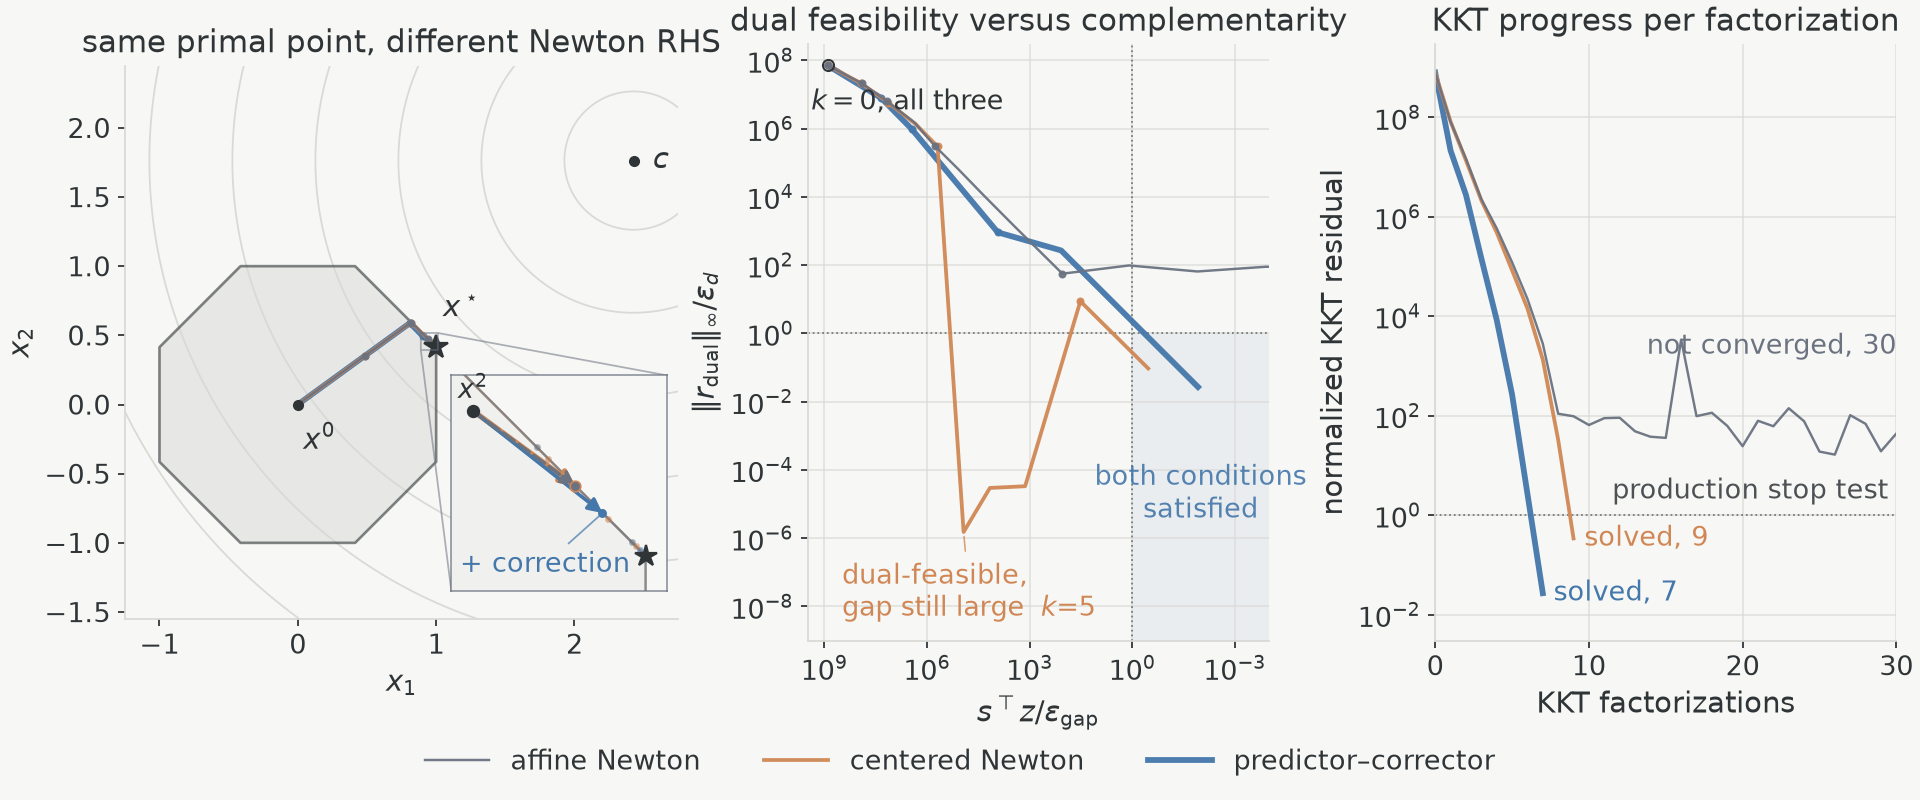

In [10]:
fig, (ax_x, ax_g, ax_k) = plt.subplots(
    1, 3, figsize=(12, 5), dpi=160, layout="constrained", width_ratios=[1.2, 1, 1])
handles = {}

# Panel 1: the physical variables. Contours are circles about c, and every method
# walks the same octagon toward the same sharp vertex.
gx, gy = np.meshgrid(np.linspace(-1.25, 2.75, 241), np.linspace(-1.55, 2.45, 241))
ax_x.contour(gx, gy, 0.5 * ((gx - c[0]) ** 2 + (gy - c[1]) ** 2),
             levels=0.5 * np.arange(0.5, 4.6, 0.6) ** 2, colors=GRID, linewidths=0.8)
ax_x.fill(OCT[:, 0], OCT[:, 1], color=GRID, alpha=0.5, lw=0)
ax_x.plot(OCT[:, 0], OCT[:, 1], color=DARK, lw=1.2, alpha=0.6)
for mode in ORDER:
    p = PATH[mode]
    ax_x.plot(p[:, 0], p[:, 1], **STYLE[mode])
    m = MARKS[MARKS < len(p)]
    ax_x.plot(p[m, 0], p[m, 1], ls="none", marker="o", ms=2.6,
              color=STYLE[mode]["color"], alpha=0.9)
ax_x.plot(*c, ls="none", marker="o", ms=4, color=DARK)
ax_x.annotate("$c$", (c[0] + 0.14, c[1] - 0.06), color=DARK)
ax_x.plot(0, 0, ls="none", marker="o", ms=4, color=DARK)
ax_x.annotate("$x^0$", (0.04, -0.32), color=DARK)
ax_x.plot(*x_star, ls="none", marker="*", ms=11, color=DARK)
ax_x.annotate("$x^\\star$", (x_star[0] + 0.05, x_star[1] + 0.22), color=DARK)
ax_x.set(xlim=(-1.25, 2.75), ylim=(-1.55, 2.45), xlabel="$x_1$", ylabel="$x_2$",
         title="same primal point, different Newton RHS")
ax_x.set_aspect("equal")

# Inset: the active vertex magnified, sited clear of the octagon and the trajectories.
# The three arrows are the three candidate steps read off one factored Jacobian at the
# single production iterate x^K_REF. All three run into the same active edge, so what
# separates them is length, not heading: the affine and centered heads coincide to
# 3e-5, and only the second-order correction carries the step further. That is the
# 9-versus-7 factorization result in local form.
axins = ax_x.inset_axes([0.59, 0.05, 0.39, 0.39], xlim=ZOOM[:2], ylim=ZOOM[2:],
                        xticks=[], yticks=[], facecolor=BG)
axins.fill(OCT[:, 0], OCT[:, 1], color=GRID, alpha=0.22, lw=0)
axins.plot(OCT[:, 0], OCT[:, 1], color=DARK, lw=1.1, alpha=0.55)
for mode in ORDER:                                   # the three runs, faint context
    p = PATH[mode][K_REF:]
    axins.plot(p[:, 0], p[:, 1], color=STYLE[mode]["color"], lw=0.9, alpha=0.30)
    axins.plot(p[:, 0], p[:, 1], ls="none", marker="o", ms=2.2,
               color=STYLE[mode]["color"], alpha=0.45)
for mode in ("center", "pc", "affine"):              # gray dashed drawn over the orange
    axins.annotate("", xy=ENDPOINT[mode], xytext=ref_x, arrowprops=dict(
        arrowstyle="-|>", shrinkA=0, shrinkB=0, color=STYLE[mode]["color"],
        lw=2.4 if mode == "center" else 1.6,
        ls="--" if mode == "affine" else "-"))
    axins.plot(*ENDPOINT[mode], ls="none", marker="o", ms=4.5 if mode == "center" else 3,
               color=STYLE[mode]["color"], zorder=4)
span = ZOOM[1] - ZOOM[0]
axins.annotate("+ correction", xy=ENDPOINT["pc"], xytext=(0.04, 0.06),
               textcoords=axins.transAxes, color=BLUE, fontsize=12, ha="left",
               va="bottom", arrowprops=dict(arrowstyle="-", lw=0.8, color=BLUE,
                                            alpha=0.7))
axins.plot(*ref_x, ls="none", marker="o", ms=5, color=DARK, zorder=5)
axins.annotate(f"$x^{K_REF}$", ref_x + np.array([0.0, 0.03]) * span, color=DARK,
               fontsize=12, ha="center", va="bottom")
axins.plot(*x_star, ls="none", marker="*", ms=10, color=DARK, zorder=5)
for side in axins.spines.values():
    side.set(color=GRAY, alpha=0.7, linewidth=0.8)
ax_x.indicate_inset_zoom(axins, edgecolor=GRAY, alpha=0.55, lw=0.8)

# Panel 2: the two conditions that actually bind here, each divided by the production
# tolerance stop_test computes at that same iterate. Large gap on the left, small on
# the right; the solved corner is lower-right.
ax_g.fill_between([1.0, 1e-4], 1e-9, 1.0, color=BLUE, alpha=0.07, lw=0)
ax_g.axvline(1.0, color=DARK, lw=0.8, ls=":", alpha=0.6)
ax_g.axhline(1.0, color=DARK, lw=0.8, ls=":", alpha=0.6)
for mode in ORDER:
    handles[mode], = ax_g.plot(GAP_R[mode], DUAL_R[mode], **STYLE[mode])
    m = MARKS[MARKS < len(GAP_R[mode])]
    ax_g.plot(GAP_R[mode][m], DUAL_R[mode][m], ls="none", marker="o", ms=2.6,
              color=STYLE[mode]["color"], alpha=0.9)
start_r = traces["pc"][0]
ax_g.plot(start_r["gap_ratio"], start_r["dual_ratio"], ls="none", marker="o", ms=5,
          mfc="none", mec=DARK, mew=0.9)
ax_g.annotate("$k=0$, all three", (2.4e9, start_r["dual_ratio"] * 0.08), color=DARK,
              fontsize=12, ha="left", va="center")
ax_g.annotate(f"dual-feasible,\ngap still large  $k$={dip['k']}",
              xy=(dip["gap_ratio"], dip["dual_ratio"]), xytext=(3e8, 2.5e-8),
              color=ORANGE, fontsize=12, ha="left", va="center",
              arrowprops=dict(arrowstyle="-", lw=0.7, color=ORANGE, alpha=0.8))
ax_g.annotate("both conditions\nsatisfied", (1e-2, 4e-6), color=BLUE, fontsize=12,
              ha="center", alpha=0.9)
ax_g.set(xscale="log", yscale="log", xlim=(3e9, 1e-4), ylim=(1e-9, 3e8),
         xlabel="$s^\\top z / \\epsilon_\\mathrm{gap}$",
         ylabel="$\\|r_\\mathrm{dual}\\|_\\infty / \\epsilon_d$",
         title="dual feasibility versus complementarity")
ax_g.grid(True, color=GRID, lw=0.7, alpha=0.8)

# Panel 3: the whole stop test in one number, against the cost that the corrector does
# not add. Below the line every production condition holds simultaneously.
ax_k.axhline(1.0, color=DARK, lw=0.8, ls=":", alpha=0.6)
ax_k.annotate("production stop test", (MAX_FACT - 0.5, 1.6), color=DARK, fontsize=12,
              ha="right", va="bottom", alpha=0.85)
for mode in ORDER:
    ax_k.plot(np.arange(len(KKT_R[mode])), KKT_R[mode], **STYLE[mode])
for mode, dx, dy, ha, va in (("pc", 0.7, 1.0, "left", "center"),
                             ("center", 0.7, 1.0, "left", "center"),
                             ("affine", 0.0, 30.0, "right", "bottom")):
    end = len(KKT_R[mode]) - 1
    ax_k.annotate(f"{status[mode]}, {end}", (end + dx, KKT_R[mode][end] * dy),
                  color=STYLE[mode]["color"], fontsize=12, ha=ha, va=va)
ax_k.set(yscale="log", xlim=(0, MAX_FACT), ylim=(3e-3, 3e9),
         xlabel="KKT factorizations", ylabel="normalized KKT residual",
         title="KKT progress per factorization")
ax_k.grid(True, color=GRID, lw=0.7, alpha=0.8)

for ax in (ax_x, ax_g, ax_k):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=3, width=0.8, labelsize=12)

fig.legend([handles[m] for m in METHODS], [LABEL[m] for m in METHODS],
           loc="outside lower center", ncol=3, frameon=False, handlelength=2.4,
           columnspacing=2.4)

Path("assets").mkdir(exist_ok=True)
fig.savefig("assets/predictor_corrector.png", dpi=160)
img = plt.imread("assets/predictor_corrector.png")
print(f"assets/predictor_corrector.png: {img.shape[1]} x {img.shape[0]} pixels")
assert img.shape[:2] == (800, 1920), img.shape
plt.show()